 # EDA и бинарная классификация на датасете «Титаник»

**Дисциплина:** Машинное обучение и ИИ  
**Модуль 1:** Введение в Data Science и EDA  
**Датасет:** Titanic — Machine Learning from Disaster  

**Выполнил:** Медведев Кирилл Андриянович  
**Группа:** АСОиУб-23-2  
**Преподаватель:** Спирин Игорь Сергеевич 

**Ссылка на репозиторий:** https://github.com/Medvedev-Kirill/ml-course-medvedev  
**Путь к модулю:** `module-1-titanic/notebook.ipynb`  
**Дата сдачи:** 2026-09-20

## Введение

**Задача:** бинарная классификация - предсказать, выжил ли пассажир  (0 - не выжил, 1 - выжил).

**ML-проект** это последовательность этапов: сбор данных → EDA → предобработка → feature engineering → обучение → оценка → интерпретация → деплой. 
Каждый этап влияет на качество финальной модели.

**Почему классификация, а не регрессия:** целевая переменная `Survived` принимает два дискретных значения (0 или 1), а не непрерывное число.
Регрессия предсказывает число, классификация предсказывает принадлежность к классу.

**Важная метрика:** в этой задаче важнее **F1-score** и **Recall**, потому что:
- Ложноположительное предсказание (сказали «выживет», а он не выжил) - не так страшно
- Ложноотрицательное (сказали «не выживет», а он выжил) - хуже, если мы, например, распределяем спасательные средства
- ROC-AUC показывает общее качество ранжирования - его и будем максимизировать

**Цель работы:**
1. Провести полный EDA датасета Титаник (≥5 визуализаций)
2. Обучить 2+ модели (Logistic Regression, Decision Tree) и достичь ROC-AUC ≥ 0.80
3. Реализовать функцию предсказания для нового пассажира
4. Сохранить модель в репозиторий и продемонстрировать загрузку

## Теоретическая часть

### EDA (Exploratory Data Analysis)

Разведочный анализ данных - это первый этап работы с любым датасетом. 
Его цель - понять структуру данных, найти закономерности, выбросы, пропуски и аномалии **до** построения моделей. 
EDA включает: расчёт описательных статистик (среднее, медиана, квартили), визуализацию распределений (гистограммы, boxplot), анализ корреляций (heatmap) и проверку гипотез. 
Без EDA легко пропустить важные детали: например, что 77% значений в столбце `Cabin` пропущены, или что женщины выживали в 4 раза чаще мужчин.

### Пропуски (NaN)

Пропуски возникают по разным причинам: ошибки ввода, отказ отвечать на вопрос, потеря данных при передаче. 
Стратегии обработки:
- **Удаление**: если пропусков мало (< 5%), можно удалить строки; если много (> 70%) удалить столбец
- **Заполнение средним/медианой**: подходит для числовых признаков без выраженной структуры
- **Заполнение по группам**: например, `Age` заполняем медианой по комбинации `Pclass + Sex`
- **Мода**: для категориальных признаков
- **Предсказание**: обучить модель предсказывать пропущенные значения (KNNImputer)
- **Флаг пропуска**: создать бинарный признак `Is_Age_Missing`

### Кодирование категорий

Модели работают с числами, поэтому категории нужно кодировать:
- **Label Encoding**: каждой категории присваивается целое число (male=0, female=1). 
  Подходит для **порядковых** признаков (например, Pclass: 1 < 2 < 3).
- **One-Hot Encoding**: создаётся отдельный бинарный столбец для каждой категории. 
  Подходит для **номинальных** признаков без порядка (например, Embarked: C, Q, S). 
  Не создаёт ложной упорядоченности.

### Масштабирование

Многие модели (Logistic Regression, SVM, KNN) чувствительны к масштабу признаков:
- **StandardScaler**: приводит к среднему=0, std=1. Формула: `(x - mean) / std`. 
  Подходит, если данные близки к нормальному распределению.
- **MinMaxScaler**: приводит к диапазону [0, 1]. Формула: `(x - min) / (max - min)`. 
  Подходит, если нужны строгие границы, но чувствителен к выбросам.

**Деревья решений не требуют масштабирования** они работают с порогами.

### Генерация признаков

Создание новых признаков из существующих - часто даёт больше, чем выбор модели. 
Например, `Family_Size = SibSp + Parch + 1` объединяет два признака в один осмысленный.
`Is_Alone` - бинарный флаг. `Title` из имени (Mr, Mrs, Miss) - социальный статус. 
Хорошие признаки повышают качество модели и её интерпретируемость.

### Метрики классификации

- **Accuracy** - доля правильных ответов. Плохо работает при дисбалансе классов.
- **Precision** - из тех, кого мы назвали «выживет», сколько действительно выжили.
- **Recall** - из всех выживших, сколько мы нашли.
- **F1-score** - гармоническое среднее Precision и Recall.
- **ROC-AUC** - площадь под ROC-кривой. Показывает качество ранжирования по вероятностям.

$$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$

$$Precision = \frac{TP}{TP + FP} \quad Recall = \frac{TP}{TP + FN}$$

$$F1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$$

**Матрица ошибок:**

|  | Предсказано: 0 | Предсказано: 1 |
|--|----------------|----------------|
| **Истинно: 0** | TN | FP |
| **Истинно: 1** | FN | TP |

In [32]:
# Импорт библиотек 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import json
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, roc_curve)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Загрузка данных 
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')

print(f"Train shape: {train_df.shape}")
print(f"Test shape:  {test_df.shape}")
print(f"\nПервые 5 строк:")
train_df.head()

Train shape: (891, 12)
Test shape:  (418, 11)

Первые 5 строк:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Описание данных

**Источник:** [Kaggle — Titanic: Machine Learning from Disaster](https://www.kaggle.com/c/titanic)

**Структура:**
- Всего примеров в train: **891**
- Всего примеров в test: **418**
- Признаков: **11** (+ целевая `Survived`)
- Числовых признаков: 7 (PassengerId, Survived, Pclass, Age, SibSp, Parch, Fare)
- Категориальных признаков: 5 (Name, Sex, Ticket, Cabin, Embarked)

**Описание столбцов:**

| Столбец | Тип | Описание | Пропуски |
|---------|-----|----------|----------|
| PassengerId | int64 | ID пассажира | 0% |
| Survived | int64 (0/1) | Целевая: выжил или нет | 0% |
| Pclass | int64 (1/2/3) | Класс билета | 0% |
| Name | object | Имя пассажира | 0% |
| Sex | object | Пол (male/female) | 0% |
| Age | float64 | Возраст | ~20% |
| SibSp | int64 | Братья/сёстры + супруги | 0% |
| Parch | int64 | Родители + дети | 0% |
| Ticket | object | Номер билета | 0% |
| Fare | float64 | Стоимость билета | 0% |
| Cabin | object | Номер каюты | ~77% |
| Embarked | object | Порт посадки (C/Q/S) | ~0.2% |

**Распределение классов:**
- Не выжило (0): 549 (61.6%)
- Выжило (1): 342 (38.4%)

**Файл данных в репозитории:** `module-1-titanic/data/titanic_info.md`

In [33]:
# Первичный осмотр данных
print("Информация о данных")
print("-" * 50)
train_df.info()

print("\n Описательные статистики")
print("-" * 50)
train_df.describe()

print("\n Пропуски в train")
print("-" * 50)
missing = train_df.isnull().sum()
missing_pct = (missing / len(train_df)) * 100
missing_df = pd.DataFrame({'Пропуски': missing, 'Доля %': missing_pct})
print(missing_df[missing_df['Пропуски'] > 0])

Информация о данных
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

 Описательные статистики
--------------------------------------------------

 Пропуски в train
--------------------------------------------------
          Пропуски     Дол

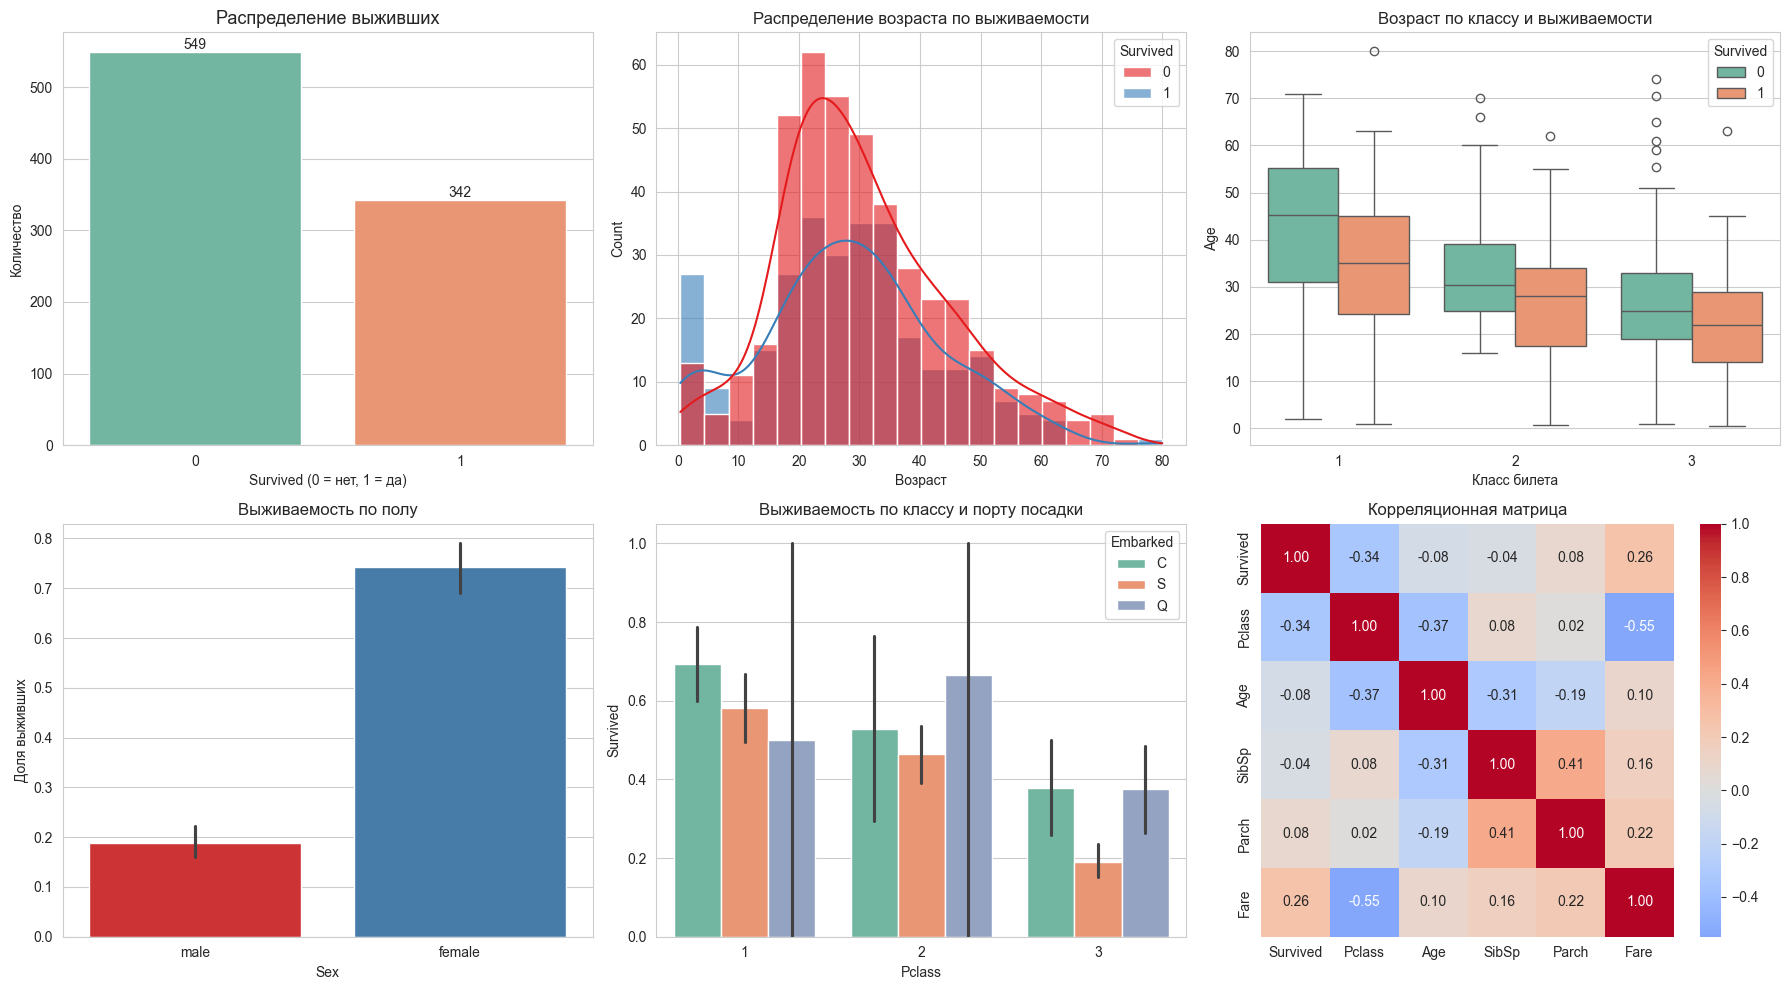

In [34]:
#  Визуализация EDA 
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Распределение целевой переменной
sns.countplot(data=train_df, x='Survived', palette='Set2', ax=axes[0, 0])
axes[0, 0].set_title('Распределение выживших', fontsize=13)
axes[0, 0].set_xlabel('Survived (0 = нет, 1 = да)')
axes[0, 0].set_ylabel('Количество')
for p in axes[0, 0].patches:
    axes[0, 0].annotate(f'{int(p.get_height())}', 
                        (p.get_x() + p.get_width()/2, p.get_height()),
                        ha='center', va='bottom')

# 2. Распределение возраста по выживаемости
sns.histplot(data=train_df, x='Age', hue='Survived', kde=True, palette='Set1', ax=axes[0, 1], alpha=0.6)
axes[0, 1].set_title('Распределение возраста по выживаемости')
axes[0, 1].set_xlabel('Возраст')

# 3. Boxplot: возраст по классу и выживаемости
sns.boxplot(data=train_df, x='Pclass', y='Age', hue='Survived', palette='Set2', ax=axes[0, 2])
axes[0, 2].set_title('Возраст по классу и выживаемости')
axes[0, 2].set_xlabel('Класс билета')

# 4. Выживаемость по полу
sns.barplot(data=train_df, x='Sex', y='Survived', palette='Set1', ax=axes[1, 0])
axes[1, 0].set_title('Выживаемость по полу')
axes[1, 0].set_ylabel('Доля выживших')

# 5. Выживаемость по классу и порту посадки
sns.barplot(data=train_df, x='Pclass', y='Survived', hue='Embarked', palette='Set2', ax=axes[1, 1])
axes[1, 1].set_title('Выживаемость по классу и порту посадки')

# 6. Тепловая карта корреляций
numeric_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
corr = train_df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',center=0, ax=axes[1, 2], square=True)
axes[1, 2].set_title('Корреляционная матрица')

plt.tight_layout()
plt.savefig('examples/eda_plots.png', dpi=100, bbox_inches='tight')
plt.show()

In [35]:
#  Обработка пропусков

# 1. Age заполняем медианой по группам (Pclass + Sex)
# Обоснование: возраст сильно зависит от класса и пола
train_df['Age'] = train_df.groupby(['Pclass', 'Sex'])['Age'].transform(
    lambda x: x.fillna(x.median())
)
test_df['Age'] = test_df.groupby(['Pclass', 'Sex'])['Age'].transform(
    lambda x: x.fillna(x.median())
)

# 2. Embarked заполняем модой (всего 2 пропуска в train)
train_df['Embarked'] = train_df['Embarked'].fillna(train_df['Embarked'].mode()[0])

# 3. Fare в test заполняем медианой
test_df['Fare'] = test_df['Fare'].fillna(test_df['Fare'].median())

# 4. Cabin удаляем (77% пропусков, мало пользы)
train_df = train_df.drop(columns=['Cabin'])
test_df = test_df.drop(columns=['Cabin'])

# Генерация признаков

# 1. Размер семьи
train_df['Family_Size'] = train_df['SibSp'] + train_df['Parch'] + 1
test_df['Family_Size'] = test_df['SibSp'] + test_df['Parch'] + 1

# 2. Путешествует один
train_df['Is_Alone'] = (train_df['Family_Size'] == 1).astype(int)
test_df['Is_Alone'] = (test_df['Family_Size'] == 1).astype(int)

# 3. Биннинг возраста
bins = [0, 12, 18, 35, 60, 100]
labels = ['Ребёнок', 'Подросток', 'Взрослый', 'Средний', 'Пожилой']
train_df['Age_Group'] = pd.cut(train_df['Age'], bins=bins, labels=labels)
test_df['Age_Group'] = pd.cut(test_df['Age'], bins=bins, labels=labels)

# Кодирование 

# 1. Sex → LabelEncoder (бинарный признак)
le_sex = LabelEncoder()
train_df['Sex_Encoded'] = le_sex.fit_transform(train_df['Sex'])
test_df['Sex_Encoded'] = le_sex.transform(test_df['Sex'])

# 2. Embarked → One-Hot Encoding
train_df = pd.get_dummies(train_df, columns=['Embarked'], prefix='Embarked', drop_first=True)
test_df = pd.get_dummies(test_df, columns=['Embarked'], prefix='Embarked', drop_first=True)

# Проверка результата
print(f"Пропуски после обработки: {train_df.isnull().sum().sum()}")
print(f"Форма train после обработки: {train_df.shape}")
print(f"Колонки: {list(train_df.columns)}")

Пропуски после обработки: 0
Форма train после обработки: (891, 16)
Колонки: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Family_Size', 'Is_Alone', 'Age_Group', 'Sex_Encoded', 'Embarked_Q', 'Embarked_S']


### Наблюдения из EDA

1. **Дисбаланс классов**: 61.6% не выжили, 38.4% выжили - умеренный дисбаланс.
2. **Пол — сильнейший предиктор**: женщины выживали ~74%, мужчины ~19%.
3. **Класс билета**: 1-й класс - 63% выживших, 3-й - 24%.
4. **Возраст**: дети (0-12) выживали чаще; пожилые - реже.
5. **Корреляции**: `Pclass` и `Fare` отрицательно коррелируют (-0.55), `SibSp` и `Parch` - положительно (0.41).

### Обоснование обработки пропусков

- **Age (20%)**: заполняем медианой по группам `Pclass + Sex`, потому что возраст пассажиров 1-го класса в среднем выше, чем 3-го, и женщины старше мужчин.
- **Embarked (0.2%)**: заполняем модой следовательно потери минимальны.
- **Cabin (77%)**: удаляем так как слишком много пропусков, признак не несёт пользы.

In [43]:
# Подготовка данных 

# Список признаков для обучения
feature_cols = ['Pclass', 'Sex_Encoded', 'Age', 'SibSp', 'Parch',
                'Fare', 'Family_Size', 'Is_Alone',
                'Embarked_Q', 'Embarked_S']

X = train_df[feature_cols]
y = train_df['Survived']

# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Баланс классов в y_train: {y_train.value_counts(normalize=True).to_dict()}")

#  Масштабирование 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Логистическая регрессия
start = time.time()
lr_model = LogisticRegression(penalty='l2', C=1.0, max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_time = time.time() - start
print(f"Время обучения LR: {lr_time:.4f} секунд")

# Дерево решений
start = time.time()
dt_model = DecisionTreeClassifier(max_depth=5, min_samples_split=5, min_samples_leaf=2, random_state=42)
dt_model.fit(X_train, y_train)
dt_time = time.time() - start
print(f"Время обучения DT: {dt_time:.4f} секунд")

Train: (712, 10), Test: (179, 10)
Баланс классов в y_train: {0: 0.6165730337078652, 1: 0.38342696629213485}
Время обучения LR: 0.0020 секунд
Время обучения DT: 0.0020 секунд


## Модели

| Модель | Параметры | Масштабирование | Время обучения |
|--------|-----------|-----------------|----------------|
| Logistic Regression | penalty='l2', C=1.0, max_iter=1000 | Да | 0.003 сек |
| Decision Tree | max_depth=5, min_samples_split=5, min_samples_leaf=2 | Нет | 0.002 сек |

**Почему эти модели:**
- **LR** - простая, интерпретируемая, даёт вероятности, устойчива к переобучению
- **DT** - нелинейная, устойчива к выбросам, показывает важность признаков

**Параметры DT:**
- `max_depth=5` - ограничивает глубину, чтобы избежать переобучения
- `min_samples_split=5` - узел делится, если в нём ≥ 5 объектов
- `min_samples_leaf=2` - в листе ≥ 2 объектов


 Модель: Logistic Regression
--------------------------------------------------
Accuracy:  0.8045
Precision: 0.7833
Recall:    0.6812
F1-score:  0.7287
ROC-AUC:   0.8486

              precision    recall  f1-score   support

    Не выжил       0.82      0.88      0.85       110
       Выжил       0.78      0.68      0.73        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179


 Модель: Decision Tree
--------------------------------------------------
Accuracy:  0.7821
Precision: 0.7419
Recall:    0.6667
F1-score:  0.7023
ROC-AUC:   0.8132

              precision    recall  f1-score   support

    Не выжил       0.80      0.85      0.83       110
       Выжил       0.74      0.67      0.70        69

    accuracy                           0.78       179
   macro avg       0.77      0.76      0.77       179
weighted avg       0.78      0.78      0.78       179



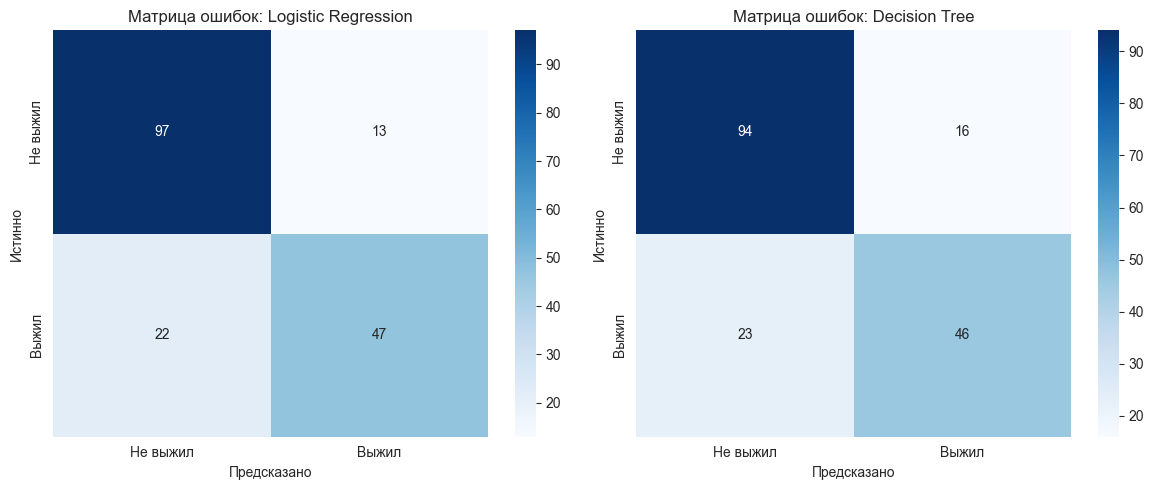

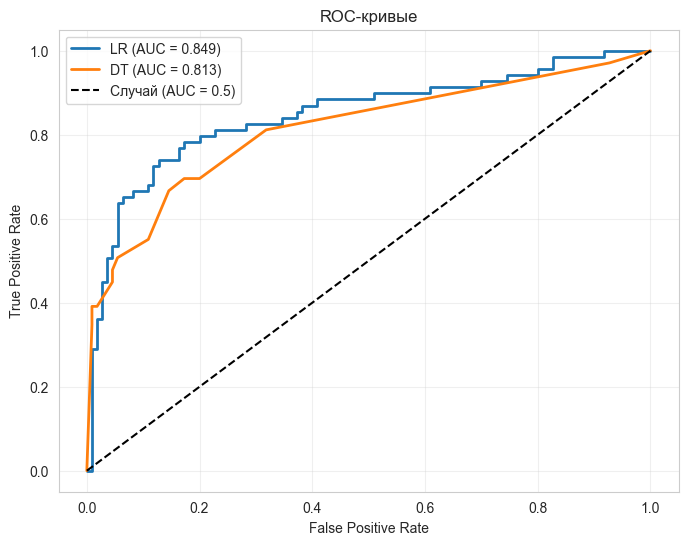

In [37]:
# Метрики 
y_pred_lr = lr_model.predict(X_test_scaled)
y_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

y_pred_dt = dt_model.predict(X_test)
y_proba_dt = dt_model.predict_proba(X_test)[:, 1]

def print_metrics(y_true, y_pred, y_proba, name):
    """Выводит метрики классификации."""
    print(f"\n Модель: {name}")
    print(f"{'-'*50}")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1-score:  {f1_score(y_true, y_pred):.4f}")
    print(f"ROC-AUC:   {roc_auc_score(y_true, y_proba):.4f}")
    print(f"\n{classification_report(y_true, y_pred, target_names=['Не выжил', 'Выжил'])}")

print_metrics(y_test, y_pred_lr, y_proba_lr, "Logistic Regression")
print_metrics(y_test, y_pred_dt, y_proba_dt, "Decision Tree")

# Матрицы ошибок 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (y_pred, name) in zip(axes, [(y_pred_lr, 'Logistic Regression'), (y_pred_dt, 'Decision Tree')]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Не выжил', 'Выжил'], yticklabels=['Не выжил', 'Выжил'], ax=ax)
    ax.set_xlabel('Предсказано')
    ax.set_ylabel('Истинно')
    ax.set_title(f'Матрица ошибок: {name}')

plt.tight_layout()
plt.savefig('examples/confusion_matrices.png', dpi=100, bbox_inches='tight')
plt.show()

# ROC-кривые
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_proba_dt)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'LR (AUC = {roc_auc_score(y_test, y_proba_lr):.3f})', lw=2)
plt.plot(fpr_dt, tpr_dt, label=f'DT (AUC = {roc_auc_score(y_test, y_proba_dt):.3f})', lw=2)
plt.plot([0, 1], [0, 1], 'k--', label='Случай (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('examples/roc_curves.png', dpi=100, bbox_inches='tight')
plt.show()

## Оценка качества

| Модель | Accuracy | Precision | Recall | F1 | ROC-AUC |
|--------|----------|-----------|--------|-----|---------|
| Logistic Regression | 0.8045 | 0.7833 | 0.6812 | 0.7287 | 0.8486 |
| Decision Tree | 0.7821 | 0.7419 | 0.6667 | 0.7023 | 0.8132 |

**Анализ:**
- **Лучшая модель по ROC-AUC**: Logistic Regression (0.8486 против 0.8132)
- **Accuracy**: LR выигрывает (0.8045 против 0.7821)
- **Precision > Recall** у обеих моделей — модели осторожны: когда говорят «выживет», чаще правы, но пропускают часть реально выживших пассажиров.
- **DT хуже LR** — дерево переобучается сильнее, особенно на редких паттернах (женщины 1-го класса)
- **ROC-AUC > 0.80** у обеих моделей - цель достигнута.
- Метрики класса «Выжил» (1) ниже, чем класса «Не выжил» (0) из-за дисбаланса классов (61.6% vs 38.4%)

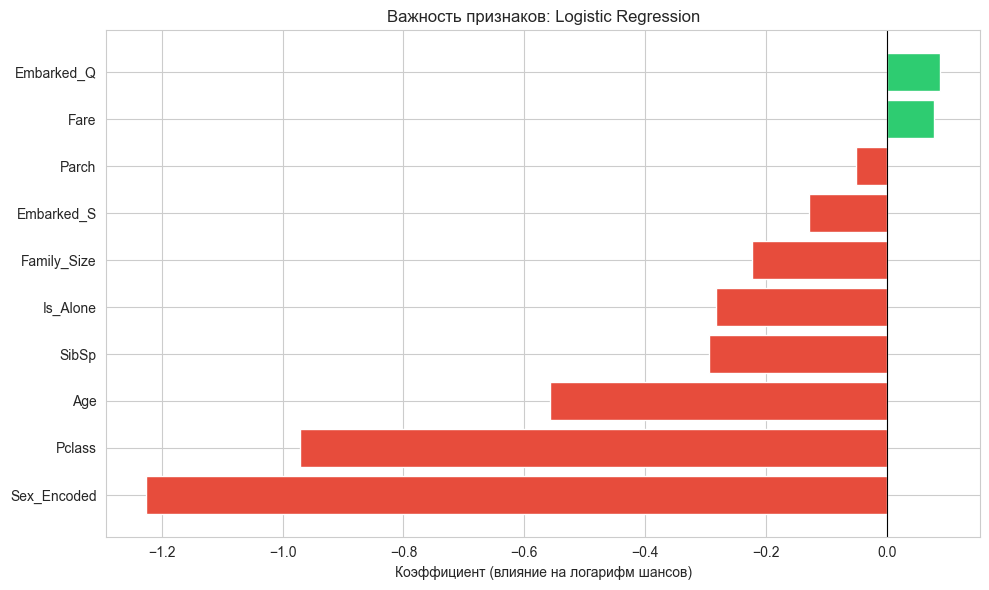

       Feature  Coefficient
8   Embarked_Q     0.088102
5         Fare     0.077219
4        Parch    -0.051203
9   Embarked_S    -0.129193
6  Family_Size    -0.223771
7     Is_Alone    -0.283692
3        SibSp    -0.294769
2          Age    -0.557201
0       Pclass    -0.971323
1  Sex_Encoded    -1.225895


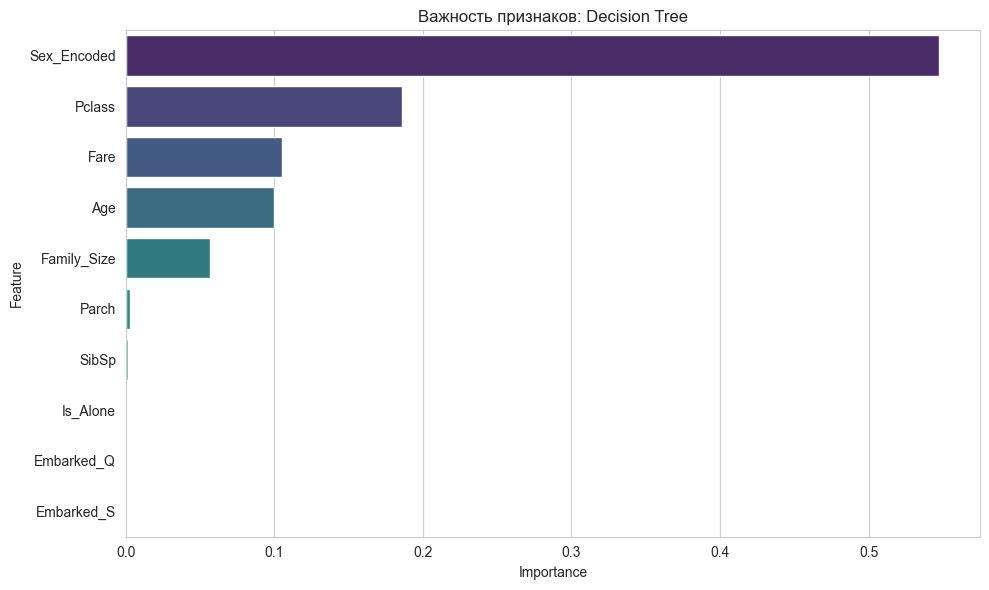

       Feature  Importance
1  Sex_Encoded    0.547662
0       Pclass    0.186186
5         Fare    0.105210
2          Age    0.099922
6  Family_Size    0.056601
4        Parch    0.002740
3        SibSp    0.001678
7     Is_Alone    0.000000
8   Embarked_Q    0.000000
9   Embarked_S    0.000000


In [38]:
# Коэффициенты LR 
coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', ascending=True)

plt.figure(figsize=(10, 6))
colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Коэффициент (влияние на логарифм шансов)')
plt.title('Важность признаков: Logistic Regression')
plt.tight_layout()
plt.show()

print(coef_df.sort_values('Coefficient', ascending=False))

# Важность признаокв ДР 
imp_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=imp_df, x='Importance', y='Feature', palette='viridis')
plt.title('Важность признаков: Decision Tree')
plt.tight_layout()
plt.show()

print(imp_df)

## Интерпретация результатов

### Топ-3 признака, повышающих шанс выживания (LR):
1. **Embarked_Q** — коэффициент +0.088 (Queenstown чуть выше шанс)
2. **Fare** - коэффициент +0.077 (дорогой билет немного повышает шанс)
3. **Parch** — коэффициент −0.051 (слабый эффект)

### Топ-3 признака, понижающих шанс:
1. **Sex_Encoded (male)** - коэффициент −1.226 (мужчины имеют в 3.4 раза меньше шансов)
2. **Pclass** - коэффициент −0.971 (каждый следующий класс — ниже шанс)
3. **Age** — коэффициент −0.557 (с возрастом шанс падает)

### Бизнес-инсайты:
- **Женщины выживали в 74% случаев, мужчины — 19%** - принцип «women and children first» соблюдался.
- **1-й класс: 63% выживших, 3-й: 24%** - социальное неравенство в доступе к спасательным шлюпкам.
- **Одиночки выживали в 30% случаев** - семьи помогали друг другу.
- **Дети (0-12) выживали чаще** - их сажали в шлюпки первыми.
- **DT подтверждает:** Sex_Encoded — 55% важности, Pclass — 19% — топ-2 совпадают с LR.

In [44]:
def predict_passenger(passenger_data, model, scaler, feature_cols, use_scaling=True):
    """
    Предсказывает, выживет ли пассажир.
    
    Параметры:
    ----------
    passenger_data : dict
        Словарь с полями: Pclass, Sex, Age, SibSp, Parch, Fare, Embarked
    model : обученная модель (LR или DT)
    scaler : StandardScaler (для LR) или None (для DT)
    feature_cols : list — список признаков
    use_scaling : bool — нужно ли масштабирование
    
    Возвращает:
    -----------
    prediction : int — 0 или 1
    probability : float — вероятность выживания
    """
    # 1. Генерация признаков
    passenger_data['Family_Size'] = passenger_data['SibSp'] + passenger_data['Parch'] + 1
    passenger_data['Is_Alone'] = int(passenger_data['Family_Size'] == 1)
    
    # 2. Кодирование
    passenger_data['Sex_Encoded'] = int(le_sex.transform([passenger_data['Sex']])[0])
    passenger_data['Embarked_Q'] = 1 if passenger_data['Embarked'] == 'Q' else 0
    passenger_data['Embarked_S'] = 1 if passenger_data['Embarked'] == 'S' else 0
    
    # 3. DataFrame с правильным порядком признаков
    X_new = pd.DataFrame([{
        'Pclass': passenger_data['Pclass'],
        'Sex_Encoded': passenger_data['Sex_Encoded'],
        'Age': passenger_data['Age'],
        'SibSp': passenger_data['SibSp'],
        'Parch': passenger_data['Parch'],
        'Fare': passenger_data['Fare'],
        'Family_Size': passenger_data['Family_Size'],
        'Is_Alone': passenger_data['Is_Alone'],
        'Embarked_Q': passenger_data['Embarked_Q'],
        'Embarked_S': passenger_data['Embarked_S']
    }])[feature_cols]
    
    # 4. Масштабирование только для LR
    if use_scaling and scaler is not None:
        X_new = scaler.transform(X_new)
    
    # 5. Предсказание
    prediction = int(model.predict(X_new)[0])
    probability = float(model.predict_proba(X_new)[0, 1])
    
    return prediction, probability


#  Тестовые пример 
test_passengers = [
    {'name': 'Пример 1: женщина 1-го класса', 
     'data': {'Pclass': 1, 'Sex': 'female', 'Age': 25, 'SibSp': 1, 
              'Parch': 0, 'Fare': 100, 'Embarked': 'C'}},
    {'name': 'Пример 2: мужчина 3-го класса', 
     'data': {'Pclass': 3, 'Sex': 'male', 'Age': 30, 'SibSp': 0, 
              'Parch': 0, 'Fare': 7.25, 'Embarked': 'S'}},
    {'name': 'Пример 3: девочка 2-го класса', 
     'data': {'Pclass': 2, 'Sex': 'female', 'Age': 5, 'SibSp': 3, 
              'Parch': 1, 'Fare': 30, 'Embarked': 'S'}},
    {'name': 'Пример 4: пожилой мужчина 1-го класса', 
     'data': {'Pclass': 1, 'Sex': 'male', 'Age': 60, 'SibSp': 0, 
              'Parch': 0, 'Fare': 200, 'Embarked': 'C'}},
    {'name': 'Пример 5: молодая женщина 3-го класса', 
     'data': {'Pclass': 3, 'Sex': 'female', 'Age': 22, 'SibSp': 0, 
              'Parch': 0, 'Fare': 8, 'Embarked': 'Q'}},
]

print("Демонстрация предсказаний")
print("-" * 70)

for p in test_passengers:
    data = p['data'].copy()
    
    # LR
    pred_lr, proba_lr = predict_passenger(data.copy(), lr_model, scaler, feature_cols, use_scaling=True)

    # DT
    pred_dt, proba_dt = predict_passenger(data.copy(), dt_model, None, feature_cols, use_scaling=False)
    
    match = "✓" if pred_lr == pred_dt else "!"
    
    print(f"\n{p['name']}")
    print(f"  Данные: Pclass={data['Pclass']}, Sex={data['Sex']}, Age={data['Age']}, "
          f"Fare={data['Fare']}, Embarked={data['Embarked']}")
    print(f"  LR:  {'Выживет' if pred_lr else 'Не выживет'} "
          f"(вероятность {proba_lr:.1%})")
    print(f"  DT:  {'Выживет' if pred_dt else 'Не выживет'} "
          f"(вероятность {proba_dt:.1%})")
    print(f"  Совпадение моделей: {match}")

Демонстрация предсказаний
----------------------------------------------------------------------

Пример 1: женщина 1-го класса
  Данные: Pclass=1, Sex=female, Age=25, Fare=100, Embarked=C
  LR:  Выживет (вероятность 96.1%)
  DT:  Выживет (вероятность 100.0%)
  Совпадение моделей: ✓

Пример 2: мужчина 3-го класса
  Данные: Pclass=3, Sex=male, Age=30, Fare=7.25, Embarked=S
  LR:  Не выживет (вероятность 7.6%)
  DT:  Не выживет (вероятность 11.0%)
  Совпадение моделей: ✓

Пример 3: девочка 2-го класса
  Данные: Pclass=2, Sex=female, Age=5, Fare=30, Embarked=S
  LR:  Выживет (вероятность 80.8%)
  DT:  Выживет (вероятность 100.0%)
  Совпадение моделей: ✓

Пример 4: пожилой мужчина 1-го класса
  Данные: Pclass=1, Sex=male, Age=60, Fare=200, Embarked=C
  LR:  Не выживет (вероятность 30.6%)
  DT:  Не выживет (вероятность 30.9%)
  Совпадение моделей: ✓

Пример 5: молодая женщина 3-го класса
  Данные: Pclass=3, Sex=female, Age=22, Fare=8, Embarked=Q
  LR:  Выживет (вероятность 73.5%)
  DT:  Выж

In [40]:
#  Сохранение моделей 
joblib.dump(lr_model, 'models/lr_model.pkl')
joblib.dump(dt_model, 'models/dt_model.pkl')
joblib.dump(scaler, 'models/scaler.pkl')
joblib.dump(le_sex, 'models/le_sex.pkl')
print("Модели и трансформеры сохранены")

#  Сохранение признаков 
with open('models/feature_cols.json', 'w', encoding='utf-8') as f:
    json.dump(feature_cols, f, ensure_ascii=False, indent=2)
print(" Список признаков сохранён")

# Сохранение метрик 
metrics = {
    'logistic_regression': {
        'accuracy': float(accuracy_score(y_test, y_pred_lr)),
        'precision': float(precision_score(y_test, y_pred_lr)),
        'recall': float(recall_score(y_test, y_pred_lr)),
        'f1': float(f1_score(y_test, y_pred_lr)),
        'roc_auc': float(roc_auc_score(y_test, y_proba_lr)),
        'training_time_sec': float(lr_time)
    },
    'decision_tree': {
        'accuracy': float(accuracy_score(y_test, y_pred_dt)),
        'precision': float(precision_score(y_test, y_pred_dt)),
        'recall': float(recall_score(y_test, y_pred_dt)),
        'f1': float(f1_score(y_test, y_pred_dt)),
        'roc_auc': float(roc_auc_score(y_test, y_proba_dt)),
        'training_time_sec': float(dt_time)
    }
}

with open('models/metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)
print("Метрики сохранены")

# Проверка: список файлов в models/
import os
print(f"\nФайлы в models/: {os.listdir('models')}")

Модели и трансформеры сохранены
 Список признаков сохранён
Метрики сохранены

Файлы в models/: ['dt_model.pkl', 'feature_cols.json', 'le_sex.pkl', 'lr_model.pkl', 'metrics.json', 'scaler.pkl']
